# 🧪 AI-Guided SIR Modeling Hackathon (2 Hours)

This notebook is the **workshop skeleton** for the **AI-Guided SIR Modeling Hackathon**.

- Dataset: **Niamey, Niger measles outbreaks** (biweekly case counts; communities A/B/C)
- Tooling: **Google Colab + Python + ChatGPT**
- Time unit: **biweeks**
- Key modeling shortcut: infectious period ≈ **2 weeks** ⇒ **γ ≈ 1 per biweek**

---

## How to use this notebook
Each section contains:
1) A **ChatGPT prompt** (Markdown) you can copy into ChatGPT  
2) A **starter code cell** (often with TODOs) to run in Colab

✅ **Rule of thumb:** Always request **plots + sanity checks** when you ask ChatGPT for help.


## 0. Setup

### ChatGPT Prompt (copy/paste)
```text
Persona:
You are an expert epidemiological modeler and Python educator.

Task:
- Write a Colab-ready setup cell: imports, basic plotting config, and a helper for reproducibility.
- If any package is missing show me how to run pip install

Constraints:
- Use numpy, scipy, pandas, matplotlib only

Verification:
- Print library versions and a simple "ready" message.
```


In [1]:
# ============================================
# 0. Setup Cell - Epidemiological Modeling
# ============================================

# --- Check and install missing packages ---
required_packages = ["numpy", "scipy", "pandas", "matplotlib"]

import importlib
import subprocess
import sys

for pkg in required_packages:
    if importlib.util.find_spec(pkg) is None:
        print(f"{pkg} not found. Installing...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

# --- Imports ---
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt

# --- Basic plotting configuration ---
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 12

# --- Reproducibility helper ---
def set_seed(seed=42):
    """
    Set random seed for reproducibility.
    """
    np.random.seed(seed)

set_seed()

# --- Print library versions ---
print("Library Versions")
print("----------------")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", plt.matplotlib.__version__)

print("\nEnvironment ready for epidemiological modeling.")

Library Versions
----------------
NumPy: 2.0.2
Pandas: 2.2.2
SciPy: 1.16.3
Matplotlib: 3.10.0

Environment ready for epidemiological modeling.


### Chat GPT Prompt to generate code to load data

```text
Persona:
You are an expert epidemiological modeler and Python educator.

Task:
- Write a Colab-ready python code to:
  - Create `data` folder if it is not exists
  - Download the csv file `https://github.com/merlinvn/ai-guided-modeling-hackathon/raw/refs/heads/main/data/niamey.csv` and put in the `data` folder.
```

In [2]:
# ============================================
# Load Dataset - Download to /data folder
# ============================================

import os
import urllib.request

# Create data folder if it does not exist
data_folder = "data"
os.makedirs(data_folder, exist_ok=True)

# File URL and destination path
url = "https://github.com/merlinvn/ai-guided-modeling-hackathon/raw/refs/heads/main/data/niamey.csv"
file_path = os.path.join(data_folder, "niamey.csv")

# Download the file if it does not already exist
if not os.path.exists(file_path):
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, file_path)
    print(f"File downloaded to: {file_path}")
else:
    print(f"File already exists at: {file_path}")

print("Dataset setup complete.")

File downloaded to: data/niamey.csv
Dataset setup complete.


## 1. Explore the Niamey Measles Data:

### Load the dataset and compute basic statistics

#### ChatGPT Prompt (copy/paste)
```text
Persona:
You are an expert epidemiological modeler and Python educator.

Context:
- Dataset contains biweekly measles case counts from Niamey, Niger
- File path: data/niamey.csv

Task:
Write Python code to:
1. Load data/niamey.csv store it to `measles_df`
2. Display the first few rows
3. Print column names and basic information about the dataset
4. Show basic statistics about dataset

Constraints
- Use pandas only
- Keep code simple and readable

```

In [3]:
# ============================================
# 1. Explore the Niamey Measles Data
# ============================================

import pandas as pd

# 1. Load dataset
file_path = "data/niamey.csv"
measles_df = pd.read_csv(file_path)

# 2. Display first few rows
print("First 5 rows of the dataset:")
print(measles_df.head())

# 3. Print column names and dataset information
print("\nColumn Names:")
print(measles_df.columns.tolist())

print("\nDataset Information:")
print(measles_df.info())

# 4. Show basic statistics
print("\nBasic Statistics:")
print(measles_df.describe())

First 5 rows of the dataset:
   biweek community  measles
0       1         A     22.0
1       2         A     27.0
2       3         A     64.0
3       4         A     84.0
4       5         A    116.0

Column Names:
['biweek', 'community', 'measles']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   biweek     48 non-null     int64  
 1   community  48 non-null     object 
 2   measles    47 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.3+ KB
None

Basic Statistics:
          biweek      measles
count  48.000000    47.000000
mean    8.500000   232.531915
std     4.658554   316.792200
min     1.000000     0.000000
25%     4.750000    13.500000
50%     8.500000    81.000000
75%    12.250000   251.500000
max    16.000000  1041.000000


### Exercise

// TODO: The prompt to explain the results in plain language


Persona:
You are an epidemiologist explaining data to a non-technical audience.

Context:
The dataset contains biweekly measles case counts from Niamey, Niger.
Basic statistics and dataset information have already been generated using pandas.

Task:
Explain the results in simple language:
1. Describe what the dataset represents.
2. Explain what the columns likely mean.
3. Summarize the key insights from the basic statistics (mean, min, max, etc.).
4. Mention any patterns or observations that might be important for understanding measles outbreaks.

Constraints:
- Avoid technical jargon.
- Use clear, simple explanations suitable for beginners.
- Keep the explanation concise (5–8 sentences).

### Explanation

The dataset records the number of measles cases reported every two weeks in a community in Niamey, Niger. It contains 48 observations, each representing a biweekly time point. The dataset has three columns: biweek, which shows the two-week time period; community, which identifies the community being observed (here labeled “A”); and measles, which shows the number of reported measles cases during that period.

From the statistics, the average number of measles cases across the periods is about 233 cases, but the large standard deviation (about 317) suggests that case numbers vary widely over time. The minimum value is 0, meaning there were periods with no reported cases, while the maximum reaches 1,041 cases, indicating a major outbreak at some point. The median value (81 cases) is much lower than the mean, suggesting that most periods had relatively fewer cases, but a few large outbreaks increased the average. Overall, the data shows that measles cases fluctuate strongly over time, which is typical for infectious disease outbreaks that occur in waves.

### Basic Plot

#### ChatGPT Prompt (copy/paste)
```text
Persona:
You are an expert epidemiological modeler and Python educator.

Context:
- Dataset is already loaded into a DataFrame called `measles_df`
- Columns: biweek, community, measles

Task:
- Plot measles cases over time for each community
- Use one time-series plot
- Label axes and include a legend
- Briefly explain what biweekly case counts mean for epidemic modeling

```

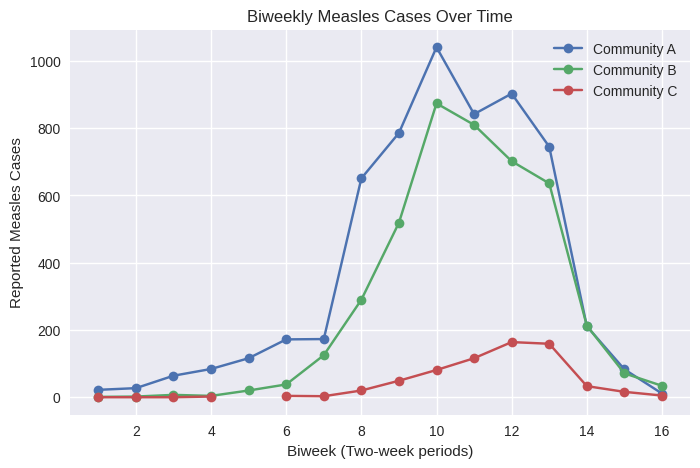

In [4]:
# ============================================
# Plot Measles Cases Over Time
# ============================================

import matplotlib.pyplot as plt

# Get unique communities
communities = measles_df["community"].unique()

# Create time-series plot
plt.figure(figsize=(8,5))

for community in communities:
    community_data = measles_df[measles_df["community"] == community]
    plt.plot(
        community_data["biweek"],
        community_data["measles"],
        marker="o",
        label=f"Community {community}"
    )

# Label axes and add title
plt.xlabel("Biweek (Two-week periods)")
plt.ylabel("Reported Measles Cases")
plt.title("Biweekly Measles Cases Over Time")

# Add legend
plt.legend()

# Show grid for readability
plt.grid(True)

plt.show()

## 2. Feature-Based Estimation: Early Growth (Quick R₀)

We estimate early exponential growth using a semi-log regression:
- Choose an early window where cases grow roughly exponentially.
- Fit `log(cases)` vs time.

### ChatGPT Prompt (copy/paste)
```text
## Persona

You are an **expert in infectious disease modeling**, with experience in early-outbreak analysis and interpretation of epidemic growth rates.

## Context

* **Disease:** Measles
* **Community:** A
* **Data:** Biweekly reported case counts
* **Epidemic phase:** Early outbreak (first ~8–10 biweeks), where case counts exhibit **exponential growth**
* **Dataset:** Already loaded as `measles_df`

### Dataset structure

Dataset Information:
`
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   biweek     48 non-null     int64  
 1   community  48 non-null     object
 2   measles    47 non-null     float64
dtypes: float64(1), int64(1), object(1)
`

## Task

Estimate the **early exponential growth rate** of the outbreak by:

1. Selecting an appropriate **early biweek window** (~ 8-10 biweeks)
2. Fitting a **log-linear model**: log(measles cases) vs. time
3. Producing a **semi-log plot** showing observed data and fitted exponential growth
4. Converting the estimated growth rate to an **approximate basic reproduction number (R₀)**, assuming:

   * Infectious removal rate: **gamma = 1 per biweek**

## Constraints

* Use **NumPy** and **SciPy** only (Matplotlib for plotting is acceptable)
* Clearly **state and explain modeling assumptions**
* Print key **statistical results** (e.g., slope, confidence intervals if available, R0)
* **Output code only** (do not execute)

## Verification / Expected Output

* A **semi-log plot** of measles cases with the fitted exponential curve
* Printed values for:

  * Estimated **growth rate (slope)**
  * Corresponding **R0 estimate**
```


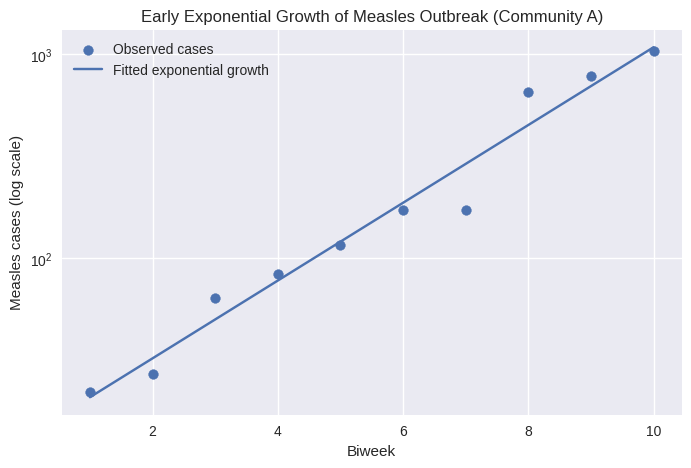

Estimated exponential growth rate (r): 0.4392081969042364
95% CI for growth rate: (np.float64(0.3739357736902228), np.float64(0.50448062011825))
Approximate R0 estimate: 1.4392081969042363


In [5]:
# ============================================
# Early Exponential Growth Estimation (Measles)
# ============================================

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# -----------------------------
# Modeling Assumptions
# -----------------------------
# 1. Early epidemic phase follows exponential growth:
#       I(t) = I0 * exp(r * t)
# 2. Taking logs gives a linear model:
#       log(I(t)) = log(I0) + r * t
# 3. Removal rate (gamma) = 1 per biweek
# 4. Approximate relationship:
#       R0 ≈ 1 + r / gamma

gamma = 1.0  # infectious removal rate per biweek

# -----------------------------
# Select early outbreak window
# -----------------------------
community = "A"
early_window = 10  # first 10 biweeks

community_data = measles_df[measles_df["community"] == community]

early_data = community_data[
    (community_data["biweek"] <= early_window) &
    (community_data["measles"] > 0)
]

t = early_data["biweek"].values
cases = early_data["measles"].values

# -----------------------------
# Log-transform cases
# -----------------------------
log_cases = np.log(cases)

# -----------------------------
# Fit log-linear model
# -----------------------------
slope, intercept, r_value, p_value, std_err = stats.linregress(t, log_cases)

growth_rate = slope

# 95% confidence interval for slope
n = len(t)
t_crit = stats.t.ppf(0.975, df=n-2)
ci_lower = slope - t_crit * std_err
ci_upper = slope + t_crit * std_err

# -----------------------------
# Estimate R0
# -----------------------------
R0_est = 1 + growth_rate / gamma

# -----------------------------
# Generate fitted curve
# -----------------------------
t_fit = np.linspace(min(t), max(t), 100)
log_fit = intercept + slope * t_fit
cases_fit = np.exp(log_fit)

# -----------------------------
# Plot semi-log figure
# -----------------------------
plt.figure(figsize=(8,5))

plt.scatter(t, cases, label="Observed cases")
plt.plot(t_fit, cases_fit, label="Fitted exponential growth")

plt.yscale("log")

plt.xlabel("Biweek")
plt.ylabel("Measles cases (log scale)")
plt.title("Early Exponential Growth of Measles Outbreak (Community A)")
plt.legend()
plt.grid(True)

plt.show()

# -----------------------------
# Print results
# -----------------------------
print("Estimated exponential growth rate (r):", growth_rate)
print("95% CI for growth rate:", (ci_lower, ci_upper))
print("Approximate R0 estimate:", R0_est)

**Goal**
Assess how sensitive the estimated basic reproduction number (**R₀**) is to the choice of early-outbreak window length.

**Method (brief)**
For a sequence of increasing early-outbreak windows (measured in biweeks):

* Fit a log-linear model to early reported measles cases to estimate the exponential growth rate.
* Convert the growth rate to **R₀** assuming a fixed infectious removal rate (γ = 1 per biweek).
* Compute a 95% confidence interval for **R₀** from the regression uncertainty.
* Visualize **R₀** and its uncertainty as a function of the window length.

**Interpretation**
Stable **R₀** estimates across window lengths suggest a robust early-growth signal, while strong variation indicates sensitivity to window choice or departures from exponential growth.

---

### Continue with the this prompt

```text
For a range of early-outbreak window lengths, plot the estimated R0 (derived from exponential growth rates) together with its 95% confidence interval, as a function of the initial period length (in biweeks).
```

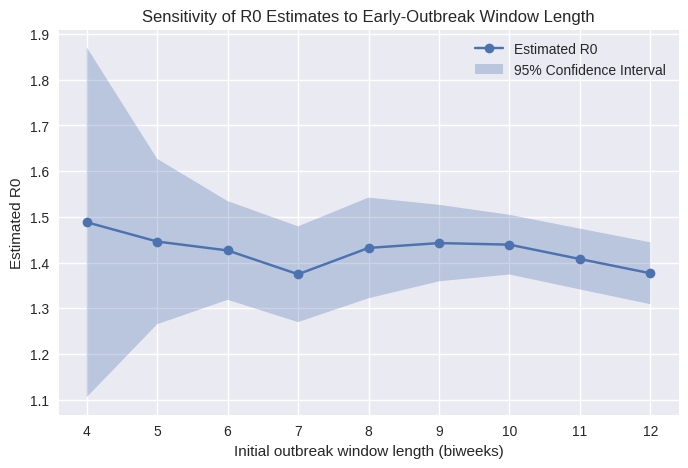

In [6]:
# =====================================================
# Sensitivity of R0 Estimates to Early-Outbreak Window
# =====================================================

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# -----------------------------
# Assumptions
# -----------------------------
# Exponential growth: I(t) = I0 * exp(r*t)
# log(I(t)) = log(I0) + r*t
# R0 ≈ 1 + r/gamma
gamma = 1.0  # infectious removal rate per biweek

# -----------------------------
# Select community A data
# -----------------------------
community_data = measles_df[measles_df["community"] == "A"]
biweek = community_data["biweek"].values
cases = community_data["measles"].values

# remove zero / missing cases for log transform
valid = (~np.isnan(cases)) & (cases > 0)
biweek = biweek[valid]
cases = cases[valid]

# -----------------------------
# Range of early-window sizes
# -----------------------------
window_lengths = np.arange(4, 13)  # 4 to 12 biweeks

R0_estimates = []
R0_lower = []
R0_upper = []

for w in window_lengths:

    mask = biweek <= w
    t = biweek[mask]
    y = cases[mask]

    log_y = np.log(y)

    # fit log-linear model
    slope, intercept, r_value, p_value, std_err = stats.linregress(t, log_y)

    # compute CI for slope
    n = len(t)
    t_crit = stats.t.ppf(0.975, df=n-2)
    slope_lower = slope - t_crit * std_err
    slope_upper = slope + t_crit * std_err

    # convert to R0
    R0 = 1 + slope / gamma
    R0_lo = 1 + slope_lower / gamma
    R0_hi = 1 + slope_upper / gamma

    R0_estimates.append(R0)
    R0_lower.append(R0_lo)
    R0_upper.append(R0_hi)

R0_estimates = np.array(R0_estimates)
R0_lower = np.array(R0_lower)
R0_upper = np.array(R0_upper)

# -----------------------------
# Plot R0 vs window length
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(window_lengths, R0_estimates, marker="o", label="Estimated R0")

plt.fill_between(
    window_lengths,
    R0_lower,
    R0_upper,
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.xlabel("Initial outbreak window length (biweeks)")
plt.ylabel("Estimated R0")
plt.title("Sensitivity of R0 Estimates to Early-Outbreak Window Length")
plt.grid(True)
plt.legend()

plt.show()

Using the above results, ask yourself and ChatGPT the follow up questions:

- Which early window length gives the most stable estimate of R0?

- Why might very short windows (e.g., 4 biweeks) produce less reliable estimates?

- What happens if you extend the window too far into the epidemic?

- Ask ChatGPT to modify the code to compute the variance of the R0 estimate across window lengths and identify the most stable region.

Then later (homeworks):

- Does the growth rate differ between communities?

- Which community had the fastest outbreak growth?

- Are the R0 estimates consistent across communities?

- Ask ChatGPT to repeat the full analysis for communities A, B, and C and plot the estimated R0 curves on the same figure.

In [7]:
# ==========================================
# Stability Analysis of R0 Estimates
# ==========================================

import numpy as np

# Convert lists to arrays if not already
R0_estimates = np.array(R0_estimates)
window_lengths = np.array(window_lengths)

# Compute variance of R0 across sliding windows
window_size = 3  # evaluate stability across 3 neighboring windows
variances = []

for i in range(len(R0_estimates) - window_size + 1):

    subset = R0_estimates[i:i+window_size]
    var = np.var(subset)

    variances.append(var)

variances = np.array(variances)

# Find most stable region
min_var_index = np.argmin(variances)

stable_windows = window_lengths[min_var_index:min_var_index+window_size]

print("Variance of R0 across sliding windows:", variances)
print("Most stable window region (biweeks):", stable_windows)
print("Corresponding R0 estimates:", R0_estimates[min_var_index:min_var_index+window_size])

Variance of R0 across sliding windows: [6.63947497e-04 9.12071525e-04 6.72247864e-04 8.96722559e-04
 1.95894151e-05 2.46496471e-04 6.53449200e-04]
Most stable window region (biweeks): [ 8  9 10]
Corresponding R0 estimates: [1.4320018  1.44261951 1.4392082 ]


## 3. Implement the SIR Model (Biweekly Units)

We use a **closed SIR** model for a single outbreak wave:
- S(t): susceptible
- I(t): infectious
- R(t): recovered

Time unit = **biweeks**.

### ChatGPT Prompt (copy/paste)
```text
Persona:
You are an expert epidemiological modeler and Python educator.

Context:
- Closed SIR model (no birth or death)
- Time unit: biweeks
- Infectious period is around 2 weeks (gamma is 1 per biweek)

Task:
Implement an SIR model using SciPy ODE solving:
- Define the SIR equations, the function name should be `sir_rhs`
- Solve over a biweekly time grid, put it in the function `simulate_sir`
- The initial parameters should include:
    - N: population size
    - I0: initial infections
    - immune_fration: fraction of population are immune
    - beta: transmission rate
    - gamma: recovery rate
- Plot S, I, R over time

Constraints:
- Use scipy.integrate.solve_ivp
- Keep code readable and commented

Verification:
- Plot S, I, R
- Verify S + I + R ~ N
```


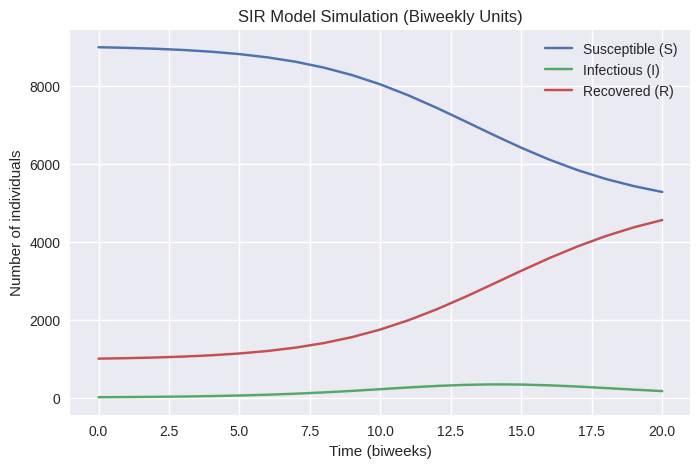

Mean(S + I + R): 10000.0
Expected population: 10000


In [8]:
# ============================================
# SIR Model Implementation (Biweekly Units)
# ============================================

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# --------------------------------------------
# SIR differential equations
# --------------------------------------------
def sir_rhs(t, y, N, beta, gamma):
    """
    Right-hand side of the SIR model.

    Parameters
    ----------
    t : float
        Time (biweeks)
    y : array
        State vector [S, I, R]
    N : int
        Total population
    beta : float
        Transmission rate
    gamma : float
        Recovery rate (per biweek)

    Returns
    -------
    dSdt, dIdt, dRdt
    """
    S, I, R = y

    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I

    return [dSdt, dIdt, dRdt]


# --------------------------------------------
# Simulation function
# --------------------------------------------
def simulate_sir(N, I0, immune_fraction, beta, gamma, t_max=20):
    """
    Simulate the SIR model over biweekly time.

    Parameters
    ----------
    N : int
        Total population size
    I0 : int
        Initial number of infectious individuals
    immune_fraction : float
        Fraction initially immune
    beta : float
        Transmission rate
    gamma : float
        Recovery rate (per biweek)
    t_max : int
        Duration of simulation in biweeks
    """

    # Initial recovered from prior immunity
    R0 = immune_fraction * N

    # Initial susceptible population
    S0 = N - I0 - R0

    # Initial state vector
    y0 = [S0, I0, R0]

    # Time grid (biweekly)
    t_eval = np.linspace(0, t_max, t_max + 1)

    # Solve ODE system
    sol = solve_ivp(
        sir_rhs,
        [0, t_max],
        y0,
        args=(N, beta, gamma),
        t_eval=t_eval
    )

    return sol


# --------------------------------------------
# Example parameters
# --------------------------------------------
N = 10000
I0 = 10
immune_fraction = 0.1
beta = 1.5
gamma = 1.0

solution = simulate_sir(N, I0, immune_fraction, beta, gamma)

t = solution.t
S, I, R = solution.y


# --------------------------------------------
# Plot S, I, R
# --------------------------------------------
plt.figure(figsize=(8,5))

plt.plot(t, S, label="Susceptible (S)")
plt.plot(t, I, label="Infectious (I)")
plt.plot(t, R, label="Recovered (R)")

plt.xlabel("Time (biweeks)")
plt.ylabel("Number of individuals")
plt.title("SIR Model Simulation (Biweekly Units)")
plt.legend()
plt.grid(True)

plt.show()


# --------------------------------------------
# Verify population conservation
# --------------------------------------------
total_population = S + I + R
print("Mean(S + I + R):", np.mean(total_population))
print("Expected population:", N)

Follow up Tasks:

- Run the model with different β values. (e.g.: 0.8, 1.0, 2.0, 3.0,...)

- When does the infection fail to grow?

- If the infectious period is 4 weeks, what should γ be?

- Change Initial Infections I0 (1 ,10, 100):
  - Does the peak size change?
  - Does the time to peak change?

- Change Population Size N (1000, 10000, 100000):
  - If you scale the population, does the shape of the epidemic curve change?

- Reproduction Number R0:
  - $R_0 = \frac{\beta}{\gamma}$

  - What happens when R₀ < 1?

  - What happens when R₀ > 1?

  - Try: beta = 0.5, 1.0, 1.5 with fixed gamma = 1

- Immunity & Vaccination:
  - Assume 20% of population is immune initially, how does herd immunity / vaccination affect the peak infection?

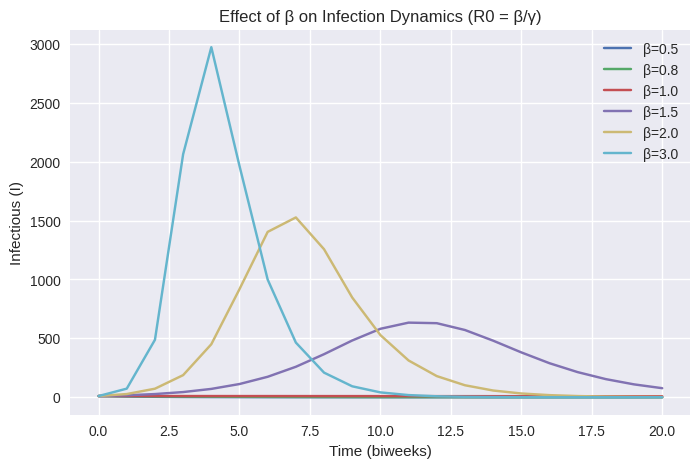

Observation:
- Infection fails to grow when R0 = β/γ < 1 (e.g., β=0.5, γ=1 → R0=0.5)
- When R0 > 1, the epidemic grows, peak size increases with β.

If infectious period is 4 weeks (2 biweeks), γ = 0.5


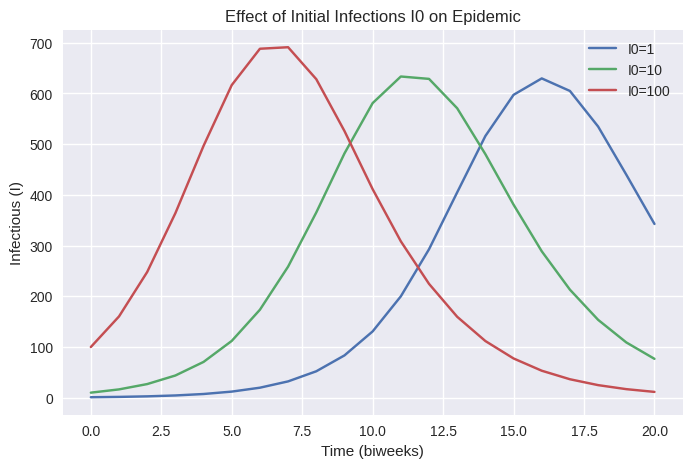

Observation:
- Larger I0 → epidemic starts earlier, peak slightly earlier
- Peak size roughly similar; shape dominated by R0 and population


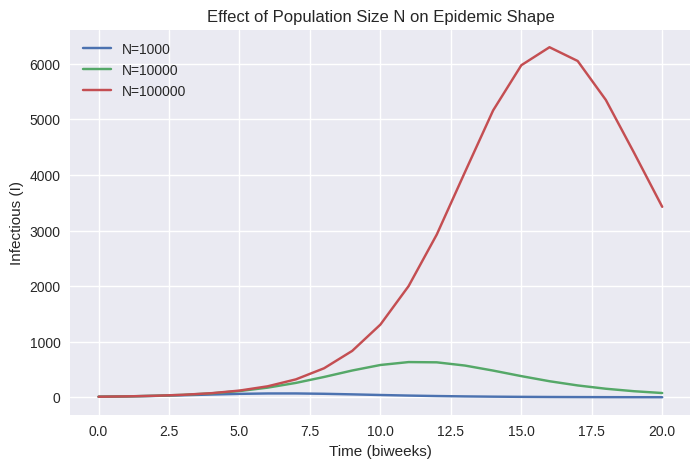

Observation:
- Scaling population changes absolute numbers
- Epidemic shape (relative dynamics) remains similar


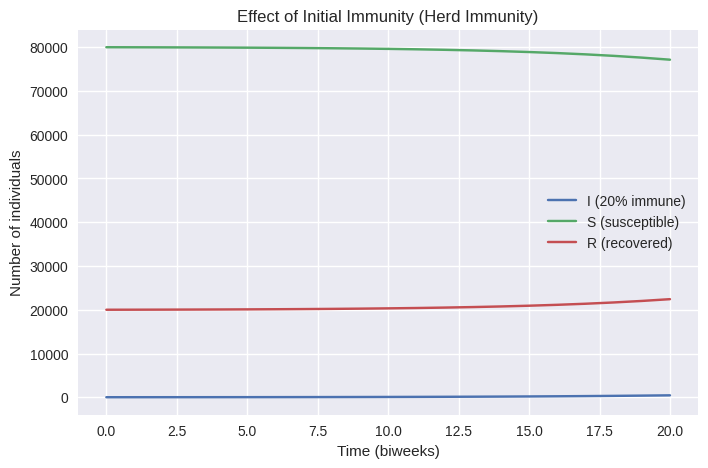

Observation:
- Herd immunity reduces peak infections
- Epidemic grows slower and may be suppressed if R0*(1-immunity) < 1


In [9]:
# ===================================================
# SIR Model Experiments – Exploring β, γ, I0, N, Immunity
# ===================================================

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# -----------------------------
# SIR model RHS
# -----------------------------
def sir_rhs(t, y, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# -----------------------------
# Simulation function
# -----------------------------
def simulate_sir(N, I0, immune_fraction, beta, gamma, t_max=20):
    R0 = immune_fraction * N
    S0 = N - I0 - R0
    y0 = [S0, I0, R0]
    t_eval = np.linspace(0, t_max, t_max + 1)
    sol = solve_ivp(sir_rhs, [0, t_max], y0, args=(N, beta, gamma), t_eval=t_eval)
    return sol

# -----------------------------
# 1. Run model with different β values
# -----------------------------
beta_values = [0.5, 0.8, 1.0, 1.5, 2.0, 3.0]
gamma_fixed = 1.0
I0 = 10
N = 10000
immune_fraction = 0.0
t_max = 20

plt.figure(figsize=(8,5))
for beta in beta_values:
    sol = simulate_sir(N, I0, immune_fraction, beta, gamma_fixed, t_max)
    plt.plot(sol.t, sol.y[1], label=f"β={beta}")
plt.xlabel("Time (biweeks)")
plt.ylabel("Infectious (I)")
plt.title("Effect of β on Infection Dynamics (R0 = β/γ)")
plt.legend()
plt.grid(True)
plt.show()

print("Observation:")
print("- Infection fails to grow when R0 = β/γ < 1 (e.g., β=0.5, γ=1 → R0=0.5)")
print("- When R0 > 1, the epidemic grows, peak size increases with β.")

# -----------------------------
# 2. Infectious period 4 weeks → γ
# -----------------------------
gamma_4weeks = 1 / 2  # 4 weeks → 2 biweeks per infectious period
print("\nIf infectious period is 4 weeks (2 biweeks), γ =", gamma_4weeks)

# -----------------------------
# 3. Change Initial Infections I0
# -----------------------------
I0_values = [1, 10, 100]
beta = 1.5
gamma = 1.0

plt.figure(figsize=(8,5))
for I0 in I0_values:
    sol = simulate_sir(N, I0, immune_fraction, beta, gamma, t_max)
    plt.plot(sol.t, sol.y[1], label=f"I0={I0}")
plt.xlabel("Time (biweeks)")
plt.ylabel("Infectious (I)")
plt.title("Effect of Initial Infections I0 on Epidemic")
plt.legend()
plt.grid(True)
plt.show()

print("Observation:")
print("- Larger I0 → epidemic starts earlier, peak slightly earlier")
print("- Peak size roughly similar; shape dominated by R0 and population")

# -----------------------------
# 4. Change Population Size N
# -----------------------------
N_values = [1000, 10000, 100000]
I0 = 10
plt.figure(figsize=(8,5))
for N in N_values:
    sol = simulate_sir(N, I0, immune_fraction, beta, gamma, t_max)
    plt.plot(sol.t, sol.y[1], label=f"N={N}")
plt.xlabel("Time (biweeks)")
plt.ylabel("Infectious (I)")
plt.title("Effect of Population Size N on Epidemic Shape")
plt.legend()
plt.grid(True)
plt.show()

print("Observation:")
print("- Scaling population changes absolute numbers")
print("- Epidemic shape (relative dynamics) remains similar")

# -----------------------------
# 5. Immunity / Vaccination
# -----------------------------
immune_fraction = 0.2  # 20% immune
sol = simulate_sir(N, I0, immune_fraction, beta, gamma, t_max)
plt.figure(figsize=(8,5))
plt.plot(sol.t, sol.y[1], label="I (20% immune)")
plt.plot(sol.t, sol.y[0], label="S (susceptible)")
plt.plot(sol.t, sol.y[2], label="R (recovered)")
plt.xlabel("Time (biweeks)")
plt.ylabel("Number of individuals")
plt.title("Effect of Initial Immunity (Herd Immunity)")
plt.legend()
plt.grid(True)
plt.show()

print("Observation:")
print("- Herd immunity reduces peak infections")
print("- Epidemic grows slower and may be suppressed if R0*(1-immunity) < 1")

## 4. Map Model Output to Observations (Incidence via ΔH)

Observed data are **biweekly case counts**, not the state `I(t)`.  
We model **incidence** using an accumulator:

- Add `H(t)` with **dH/dt = β S I / N**  
- Predicted biweekly counts ≈ **ΔH** over each biweek interval

### ChatGPT Prompt (with the same chat session of the above SIR model chat or copy along the model code)

```text
Persona:
You are an expert epidemic modeler.

Context:
- Observed data are biweekly case counts (incidence) can be loaded as:

measles_df = pd.read_csv("data/niamey.csv")

dfA = (
    measles_df
    .loc[measles_df["community"] == "A", ["biweek", "measles"]]
    .dropna(subset=["measles"])
    .copy()
)


  - dfA["biweek"] contains the biweekly time index

  - dfA["measles"] contains observed biweekly incidence (number of cases)

- SIR model outputs states

Task:

Extend the SIR model by:
- Adding H(t) with dH/dt = beta*S*I/N
- Computing predicted biweekly cases as delta_H aligned to biweeks

Then:
- Plot observed measles incidence (dfA["measles"])

- Overlay simulated biweekly incidence (delta_H) on the same figure

- Use t[1:] when plotting delta_H as len(t) is different from len(delta_h) by 1 unit

Constraints:
- Keep code minimal and readable
- Return the full block code with comments to explain in details.

```


## 5. Fit Parameters by Least Squares

We fit parameters by minimizing squared error between observed counts and predicted ΔH.

Remember to edit the interface of the SIR model to match with the generated model in the previous step.

### ChatGPT Prompt (copy/paste)
```text
## Persona

You are an **expert in numerical optimization for epidemic models**, with experience fitting compartmental models to incidence data using nonlinear least squares.

---

## Data

We have **biweekly measles incidence data** for **Community A**:

measles_df = pd.read_csv("data/niamey.csv")

dfA = (
    measles_df
    .loc[measles_df["community"] == "A", ["biweek", "measles"]]
    .dropna(subset=["measles"])
    .copy()
)

* `dfA["biweek"]` → biweekly time index
* `dfA["measles"]` → observed biweekly incidence (case counts)

---

## Model

We use an SIR model that returns simulated incidence:


def simulate_sir(N, I0, immune_fraction, beta, gamma, t_max, dt=1):
    """
    Simulate SIR model on a biweekly time grid.

    Parameters
    ----------
    N : population size
    I0 : initial infections
    immune_fraction : fraction immune at start
    beta : transmission rate
    gamma : recovery rate (per biweek)
    t_max : duration of simulation (biweeks)
    dt : output step (biweeks)

    Returns
    -------
    t : time grid
    sol : solution object
    delta_H : predicted incidence per biweek
    """
---

## Objective

Fit model parameters to the observed incidence data using **nonlinear least squares**.

### Parameters to estimate:

* `N` (population size)
* `beta` (transmission rate)
* `I0` (initial infected)
* `immune_fraction` (Fraction immune at start)

### Fixed parameter:

* `gamma = 1.0`

---

## Initialization Strategy

Use an early-growth estimate:

* Estimated basic reproduction number:

  R_0 = 1.443

* Since ( R_0 = beta / gamma ), initialize beta_0 = 1.443

Choose reasonable initial guesses and bounds:

* `N` within plausible community size in range of (1000, 10000)
* `beta > 0` in the range of (1.0, 10.0)
* `I0 ≥ 1` in the range of (1,50)
* `immune_fraction` in the range of (0.1,0.4)

---

## Optimization Requirements

* Use `scipy.optimize.least_squares`
* Fit by minimizing SSE = (Observed - Predicted)^2
* Ensure runtime is suitable for a workshop (avoid heavy MCMC or expensive methods)

---

## Verification & Output

After fitting:

1. Overlay observed and fitted incidence curves
2. Print:

   * Best-fit parameter values
   * Sum of squared errors (SSE)

---

## Expected Deliverables

* Residual function definition
* Call to `least_squares`
* Overlay plot (observed vs fitted)
* Printed parameter estimates and SSE
* Clean, reproducible workshop-ready code
```


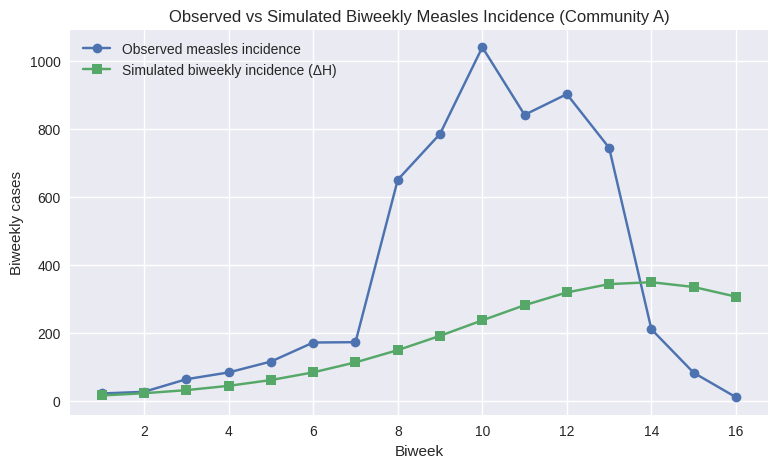

Mean(S + I + R): 10000.0
Expected population N: 10000

First few simulated biweekly incidence values (delta_H):
[ 16.11237137  22.72189045  31.89852174  44.53049715  61.53632063
  84.20189625 113.57937248 149.57381616 191.68616197 237.27935581]


In [10]:
# ==========================================================
# 4. Map SIR Model Output to Observed Biweekly Incidence
# ==========================================================
# Goal:
# - Observed data are biweekly case counts (incidence), not the infectious state I(t)
# - To compare model output to the data, we add an accumulator H(t)
# - H(t) tracks cumulative infections over time
# - The predicted number of new cases in each biweek is approximated by:
#       delta_H = H(t_k) - H(t_{k-1})
# - We then overlay observed biweekly measles cases with simulated biweekly incidence

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Load observed incidence data for Community A
# ----------------------------------------------------------
measles_df = pd.read_csv("data/niamey.csv")

dfA = (
    measles_df
    .loc[measles_df["community"] == "A", ["biweek", "measles"]]
    .dropna(subset=["measles"])
    .copy()
)

# ----------------------------------------------------------
# Extended SIR model with cumulative incidence H(t)
# ----------------------------------------------------------
# State variables:
#   S(t): susceptible
#   I(t): infectious
#   R(t): recovered
#   H(t): cumulative number of infections
#
# Infection flow:
#   beta * S * I / N
#
# Since H(t) accumulates all new infections:
#   dH/dt = beta * S * I / N
# This allows us to recover model-predicted incidence over each biweek
# by taking differences in H between successive time points.

def sir_incidence_rhs(t, y, N, beta, gamma):
    S, I, R, H = y

    infection_rate = beta * S * I / N

    dSdt = -infection_rate
    dIdt = infection_rate - gamma * I
    dRdt = gamma * I
    dHdt = infection_rate

    return [dSdt, dIdt, dRdt, dHdt]

# ----------------------------------------------------------
# Simulation function
# ----------------------------------------------------------
# This solves the SIR+H system on a biweekly grid.
# The returned delta_H gives predicted biweekly incidence.

def simulate_sir_incidence(N, I0, immune_fraction, beta, gamma, t_max):
    # Initial recovered/immune population
    R0_init = immune_fraction * N

    # Initial susceptible population
    S0 = N - I0 - R0_init

    # Initial cumulative infections
    # Start H at 0 so that differences in H represent newly generated incidence
    H0 = 0.0

    # Initial state vector
    y0 = [S0, I0, R0_init, H0]

    # Biweekly time grid: 0, 1, 2, ..., t_max
    t_eval = np.arange(0, t_max + 1, 1)

    # Solve the ODE system
    sol = solve_ivp(
        sir_incidence_rhs,
        [0, t_max],
        y0,
        t_eval=t_eval,
        args=(N, beta, gamma)
    )

    return sol

# ----------------------------------------------------------
# Example parameter values
# ----------------------------------------------------------
# These are example values for demonstration.
# You can adjust them later to improve the fit to the observed data.
N = 10000
I0 = 10
immune_fraction = 0.10
beta = 1.5
gamma = 1.0

# Match simulation length to observed biweeks
t_max = int(dfA["biweek"].max())

# Run simulation
sol = simulate_sir_incidence(
    N=N,
    I0=I0,
    immune_fraction=immune_fraction,
    beta=beta,
    gamma=gamma,
    t_max=t_max
)

# ----------------------------------------------------------
# Extract model states
# ----------------------------------------------------------
t = sol.t
S, I, R, H = sol.y

# ----------------------------------------------------------
# Compute predicted biweekly incidence
# ----------------------------------------------------------
# H is cumulative infections, so the increment over each interval
# approximates the number of new infections during that biweek.
#
# If t has length K, then diff(H) has length K-1
# Therefore, when plotting delta_H, use t[1:] so the x-axis matches.

delta_H = np.diff(H)

# ----------------------------------------------------------
# Plot observed vs simulated biweekly incidence
# ----------------------------------------------------------
plt.figure(figsize=(9, 5))

# Observed incidence from the dataset
plt.plot(
    dfA["biweek"],
    dfA["measles"],
    marker="o",
    label="Observed measles incidence"
)

# Simulated biweekly incidence from the model
plt.plot(
    t[1:],
    delta_H,
    marker="s",
    label="Simulated biweekly incidence (ΔH)"
)

plt.xlabel("Biweek")
plt.ylabel("Biweekly cases")
plt.title("Observed vs Simulated Biweekly Measles Incidence (Community A)")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------------------------------------
# Optional: verify conservation of population
# ----------------------------------------------------------
total_population = S + I + R
print("Mean(S + I + R):", np.mean(total_population))
print("Expected population N:", N)

# ----------------------------------------------------------
# Optional: inspect predicted incidence values
# ----------------------------------------------------------
print("\nFirst few simulated biweekly incidence values (delta_H):")
print(delta_H[:10])

### Epidemiological Interpretation

- What is the estimated basic reproduction number? $R_0 = \frac{\beta}{\gamma}$
    - Is it reasonable for measles?

- What proportion of the population was initially susceptible?

- Does the fitted population size N seem realistic for the community?

- What fraction of the population gets infected during the epidemic? ${Attack Rate} = \frac{H_{final}}{N}$

### Things to explore later (optional)

- How sensitive are results to the initial guess? local vs global optima.

- Try different starting values for:

    - N

    - beta

    - I_0

    - immune_fraction

- Fix `N` and refit the model.

  - Does the fit improve or worsen?

- What happens if you fix immune_fraction and only fit β and I₀?

- Which parameter affects peak height the most?

- The effects of lower bounds and upper bounds

- Repeat the process for community B and C.

## Sensitivity of fixed beta on min SSE (optional)


Write a full detail prompt based on this is the basic prompt as your homework, code below just for example

```
generate code to see sensitivity of beta (from 0 to 10) on min SSE

```

Persona:
You are an expert infectious disease modeler and scientific Python developer with strong experience in epidemiological parameter estimation.

Context:
We are modeling a measles outbreak using a deterministic **SIR model with incidence reconstruction**.

Observed data are **biweekly measles case counts** from Niamey, Niger. The dataset has already been loaded as:

```python
measles_df = pd.read_csv("data/niamey.csv")
```

Community A data are prepared as:

```python
dfA = (
    measles_df
    .loc[measles_df["community"] == "A", ["biweek", "measles"]]
    .dropna(subset=["measles"])
    .copy()
)
```

* `dfA["biweek"]` contains the biweekly time index
* `dfA["measles"]` contains observed biweekly incidence

The SIR model is defined as:

[
\frac{dS}{dt} = -\beta \frac{SI}{N}
]

[
\frac{dI}{dt} = \beta \frac{SI}{N} - \gamma I
]

[
\frac{dR}{dt} = \gamma I
]

To match **observed incidence data**, the model includes a cumulative infection variable (H(t)):

[
\frac{dH}{dt} = \beta \frac{SI}{N}
]

The **predicted biweekly cases** are computed as:

[
\Delta H_k = H(t_k) - H(t_{k-1})
]

These predicted values are compared to observed measles cases.

Task:

Write Python code to perform a **sensitivity analysis of β (transmission rate)** on the minimum **sum of squared errors (SSE)**.

Steps:

1. Define the extended **SIR + H model** using `scipy.integrate.solve_ivp`.

2. Simulate the model over the same biweekly time grid as the observed data.

3. Compute predicted incidence as `delta_H = np.diff(H)`.

4. Compute the **sum of squared errors (SSE)** between:

   observed_cases = dfA["measles"]
   predicted_cases = delta_H

5. Perform a sensitivity analysis where **β varies from 0 to 10** (for example using 100 evenly spaced values).

6. For each β value:

   * Run the SIR simulation
   * Compute predicted incidence
   * Calculate the SSE

7. Store the SSE for each β value.

Output:

The code should produce:

1. A plot showing:

   β (x-axis)
   SSE (y-axis)

2. Print the β value that produces the **minimum SSE**.

3. Display something like:

```
Best beta: ...
Minimum SSE: ...
```

Constraints:

* Use **NumPy, SciPy, Pandas, Matplotlib only**
* Use `scipy.integrate.solve_ivp` for solving the ODE system
* Keep the code **simple, readable, and well commented**

Verification / Expected Output:

The code should:

* Simulate the epidemic model repeatedly for β ∈ [0,10]
* Compute SSE for each β
* Plot the **SSE curve**
* Identify the **β value that best fits the observed incidence**


Best beta: 1.7171717171717171
Minimum SSE: 532103.118796072


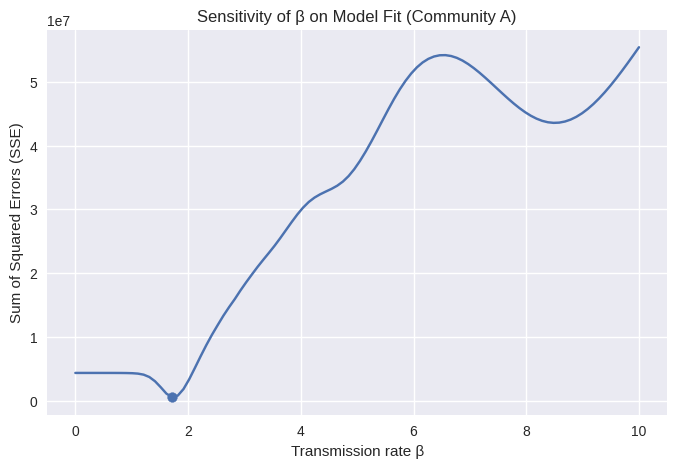

In [11]:
# ==========================================================
# Sensitivity Analysis: Fixed Beta (0 → 10) vs Minimum SSE
# ==========================================================
# Goal:
# Evaluate how the transmission rate β affects model fit.
# For each β value in [0,10], we simulate the SIR+H model,
# compute predicted incidence (ΔH), and calculate SSE
# between predicted and observed biweekly measles cases.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ----------------------------------------------------------
# Load observed data
# ----------------------------------------------------------
measles_df = pd.read_csv("data/niamey.csv")

dfA = (
    measles_df
    .loc[measles_df["community"] == "A", ["biweek", "measles"]]
    .dropna(subset=["measles"])
    .copy()
)

observed_cases = dfA["measles"].values
t_obs = dfA["biweek"].values
t_max = int(t_obs.max())

# ----------------------------------------------------------
# SIR + H model
# ----------------------------------------------------------
def sir_incidence_rhs(t, y, N, beta, gamma):
    S, I, R, H = y
    infection = beta * S * I / N

    dSdt = -infection
    dIdt = infection - gamma * I
    dRdt = gamma * I
    dHdt = infection

    return [dSdt, dIdt, dRdt, dHdt]

# ----------------------------------------------------------
# Simulation function
# ----------------------------------------------------------
def simulate_incidence(beta, N=10000, I0=10, immune_fraction=0.1, gamma=1.0):

    R0_init = immune_fraction * N
    S0 = N - I0 - R0_init
    H0 = 0

    y0 = [S0, I0, R0_init, H0]

    t_eval = np.arange(0, t_max + 1, 1)

    sol = solve_ivp(
        sir_incidence_rhs,
        [0, t_max],
        y0,
        args=(N, beta, gamma),
        t_eval=t_eval
    )

    S, I, R, H = sol.y

    # predicted incidence
    delta_H = np.diff(H)

    return delta_H

# ----------------------------------------------------------
# Compute SSE
# ----------------------------------------------------------
def compute_sse(beta):

    pred = simulate_incidence(beta)

    # align length with observations
    pred = pred[:len(observed_cases)]

    sse = np.sum((observed_cases - pred)**2)

    return sse

# ----------------------------------------------------------
# Sensitivity of beta
# ----------------------------------------------------------
beta_values = np.linspace(0, 10, 100)
sse_values = []

for beta in beta_values:
    sse = compute_sse(beta)
    sse_values.append(sse)

sse_values = np.array(sse_values)

# ----------------------------------------------------------
# Find best beta
# ----------------------------------------------------------
best_index = np.argmin(sse_values)
best_beta = beta_values[best_index]
min_sse = sse_values[best_index]

print("Best beta:", best_beta)
print("Minimum SSE:", min_sse)

# ----------------------------------------------------------
# Plot sensitivity curve
# ----------------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(beta_values, sse_values)
plt.scatter(best_beta, min_sse)

plt.xlabel("Transmission rate β")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.title("Sensitivity of β on Model Fit (Community A)")
plt.grid(True)

plt.show()

## 6. Poisson Likelihood Inference (Counts)

For count data:
- $( y_t \sim \text{Poisson}(\mu_t) )$
- $( \mu_t = \rho \cdot \Delta H_t )$

where **ρ** is a reporting/ascertainment fraction.

### ChatGPT Prompt (copy/paste)
```text
# Persona

You are an **expert in numerical optimization for epidemic models**, with experience fitting compartmental models to incidence data using likelihood-based methods.

---

# Data

We have **biweekly measles incidence data** for **Community A**:

measles_df = pd.read_csv("data/niamey.csv")

dfA = (
    measles_df
    .loc[measles_df["community"] == "A", ["biweek", "measles"]]
    .dropna(subset=["measles"])
    .copy()
)

t_obs = dfA["biweek"].values
y_obs = dfA["measles"].values


* `t_obs` → biweekly time index
* `y_obs` → observed biweekly incidence (case counts)

---

# Model

We use an SIR model that returns simulated incidence:


def simulate_sir(N, I0, immune_fraction, beta, gamma, t_max, dt=1):
    """
    Simulate SIR model on a biweekly time grid.

    Parameters
    ----------
    N : population size
    I0 : initial infections
    immune_fraction : fraction immune at start
    beta : transmission rate
    gamma : recovery rate (per biweek)
    t_max : duration of simulation (biweeks)
    dt : output step (biweeks)

    Returns
    -------
    t : time grid
    sol : solution object
    delta_H : predicted incidence per biweek
    """

---

# Objective

Fit model parameters to the observed incidence data using **maximum likelihood under a Poisson observation model**.

Assume a Poisson observation model:

Y_t ~ Poisson(p * λ_t)

where:
- Y_t = observed incidence
- λ_t = model-predicted incidence (delta_H)
- p = reporting probability

---
Parameters to Estimate

N : population size  
beta : transmission rate  
I0 : initial infections  
immune_fraction : fraction immune at start

Observation parameter:

p : reporting probability

### Fixed parameter:

* `gamma = 1.0`

---

# Initialization Strategy

Use early-growth estimate: R_0 = 1.443

Since: R_0 = beta / gamma

Initialize: beta_0 = 1.443

Use reasonable bounds:

* `N` within plausible community size in range of (1000, 10000)
* `beta > 0` in the range of (1.0, 5.0)
* `I0 ≥ 1` in the range of (1,50)
* `immune_fraction` in the range of (0,0.4)
* p reporting probability in the range of (0.8,1.0)

---

# Optimization Requirements

Use `scipy.optimize.minimize` using Powell method.

Minimize the **negative Poisson log-likelihood**:

-log L(theta) = sum_t (p*lambda_t - y_t * log(p*lambda_t)

(omit constant log(y_t!) term)

- Add small epsilon to avoid `log(0)`.

- The SIR simulator may return incidence values that correspond to intervals between time points, producing len(delta_H) = len(t_sim) - 1 some code like this could help.

if len(delta_H) == len(t_sim) - 1:
        t_sim = t_sim[:-1]

- Ensure runtime is suitable for a workshop (no MCMC).

---

# Verification & Output

After fitting:

1. Overlay observed and fitted incidence curves
2. Print:

   * Best-fit parameter values
   * Final negative log-likelihood

---

# Expected Deliverables

* Negative log-likelihood function definition
* Call to optimizer
* Overlay plot (observed vs fitted incidence)
* Printed parameter estimates
* Clean, reproducible workshop-ready code
* Proper numerical safeguards (`epsilon` for stability)

```



===== Optimization Results =====
Best-fit N: 9999.999991673709
Best-fit beta: 1.7414902110479
Best-fit I0: 3.6113163267309236
Best-fit immune_fraction: 0.044247486462009704
Best-fit reporting probability p: 0.9920956157088201
Final negative log-likelihood: -31882.90556203376


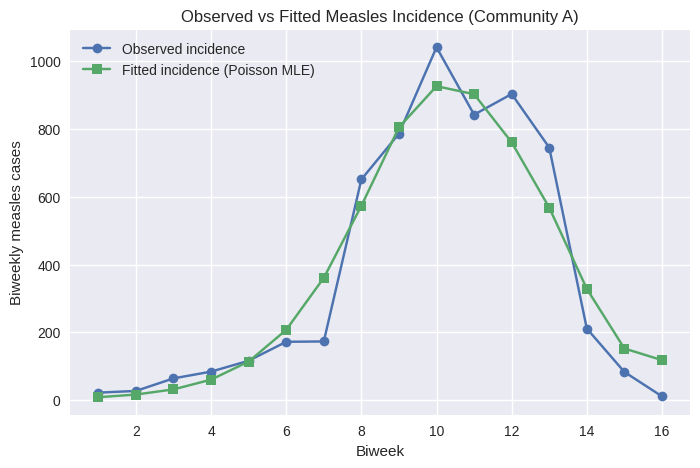

In [12]:
# ==========================================================
# 6. Poisson Likelihood Inference for SIR Model (Counts)
# ==========================================================
# Fit SIR model parameters to observed biweekly measles incidence
# using maximum likelihood under a Poisson observation model.
#
# Y_t ~ Poisson(p * λ_t)
#
# where:
#   Y_t = observed incidence
#   λ_t = model predicted incidence (ΔH)
#   p   = reporting probability
#
# Optimization: scipy.optimize.minimize (Powell)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

# ----------------------------------------------------------
# Load observed data
# ----------------------------------------------------------
measles_df = pd.read_csv("data/niamey.csv")

dfA = (
    measles_df
    .loc[measles_df["community"] == "A", ["biweek", "measles"]]
    .dropna(subset=["measles"])
    .copy()
)

t_obs = dfA["biweek"].values
y_obs = dfA["measles"].values
t_max = int(t_obs.max())

# ----------------------------------------------------------
# SIR + cumulative infections model
# ----------------------------------------------------------
def sir_rhs(t, y, N, beta, gamma):
    S, I, R, H = y

    infection = beta * S * I / N

    dSdt = -infection
    dIdt = infection - gamma * I
    dRdt = gamma * I
    dHdt = infection

    return [dSdt, dIdt, dRdt, dHdt]


# ----------------------------------------------------------
# SIR simulator returning incidence ΔH
# ----------------------------------------------------------
def simulate_sir(N, I0, immune_fraction, beta, gamma, t_max, dt=1):

    R0_init = immune_fraction * N
    S0 = N - I0 - R0_init
    H0 = 0

    y0 = [S0, I0, R0_init, H0]

    t_eval = np.arange(0, t_max + dt, dt)

    sol = solve_ivp(
        sir_rhs,
        [0, t_max],
        y0,
        args=(N, beta, gamma),
        t_eval=t_eval,
        vectorized=False
    )

    t_sim = sol.t
    S, I, R, H = sol.y

    # incidence per biweek
    delta_H = np.diff(H)

    # align lengths if needed
    if len(delta_H) == len(t_sim) - 1:
        t_sim = t_sim[:-1]

    return t_sim, sol, delta_H


# ----------------------------------------------------------
# Negative Poisson log-likelihood
# ----------------------------------------------------------
def neg_poisson_loglik(theta):

    N, beta, I0, immune_fraction, p = theta

    gamma = 1.0
    epsilon = 1e-9

    # enforce parameter constraints manually
    if N <= 0 or beta <= 0 or I0 < 1 or immune_fraction < 0 or immune_fraction > 1 or p <= 0 or p > 1:
        return np.inf

    try:

        t_sim, sol, delta_H = simulate_sir(
            N=N,
            I0=I0,
            immune_fraction=immune_fraction,
            beta=beta,
            gamma=gamma,
            t_max=t_max
        )

        # align with observation length
        delta_H = delta_H[:len(y_obs)]

        lambda_t = p * delta_H

        # avoid log(0)
        lambda_t = np.maximum(lambda_t, epsilon)

        # negative Poisson log-likelihood
        nll = np.sum(lambda_t - y_obs * np.log(lambda_t))

        return nll

    except Exception:
        return np.inf


# ----------------------------------------------------------
# Initial parameter guesses
# ----------------------------------------------------------
beta_0 = 1.443

theta0 = [
    5000,       # N
    beta_0,     # beta
    10,         # I0
    0.1,        # immune_fraction
    0.9         # reporting probability
]

# ----------------------------------------------------------
# Parameter bounds
# ----------------------------------------------------------
bounds = [
    (1000, 10000),   # N
    (1.0, 5.0),      # beta
    (1, 50),         # I0
    (0.0, 0.4),      # immune_fraction
    (0.8, 1.0)       # p
]

# ----------------------------------------------------------
# Optimization
# ----------------------------------------------------------
result = minimize(
    neg_poisson_loglik,
    theta0,
    method="Powell",
    bounds=bounds,
    options={"maxiter": 200}
)

N_hat, beta_hat, I0_hat, immune_hat, p_hat = result.x

print("\n===== Optimization Results =====")
print("Best-fit N:", N_hat)
print("Best-fit beta:", beta_hat)
print("Best-fit I0:", I0_hat)
print("Best-fit immune_fraction:", immune_hat)
print("Best-fit reporting probability p:", p_hat)
print("Final negative log-likelihood:", result.fun)

# ----------------------------------------------------------
# Simulate model using best-fit parameters
# ----------------------------------------------------------
t_sim, sol, delta_H = simulate_sir(
    N=N_hat,
    I0=I0_hat,
    immune_fraction=immune_hat,
    beta=beta_hat,
    gamma=1.0,
    t_max=t_max
)

predicted_cases = p_hat * delta_H
predicted_cases = predicted_cases[:len(y_obs)]

# ----------------------------------------------------------
# Plot observed vs fitted incidence
# ----------------------------------------------------------
plt.figure(figsize=(8,5))

plt.plot(
    t_obs,
    y_obs,
    "o-",
    label="Observed incidence"
)

plt.plot(
    t_obs,
    predicted_cases,
    "s-",
    label="Fitted incidence (Poisson MLE)"
)

plt.xlabel("Biweek")
plt.ylabel("Biweekly measles cases")
plt.title("Observed vs Fitted Measles Incidence (Community A)")
plt.legend()
plt.grid(True)

plt.show()

## 7. Quick Uncertainty: Profile Likelihood for β (Optional)

### ChatGPT Prompt (copy/paste, continue with the likelihood chat)
```text
Persona:
You are an expert in likelihood-based inference.

Context:
- We already have a Poisson likelihood fit
- We want uncertainty for beta

Task:
Create a profile likelihood for beta:
1) Fix beta over a grid range (1.0, 5.0)
2) Optimize N, I0, immune_fraction, and p for each beta

* `N` within plausible community size range (1000, 10000)
* `I0 ≥ 1` (1,50)
* `immune_fraction` in the range of (0,0.4)
* p reporting probability in the range of (0.8,1.0)

3) Plot profile NLL(beta)

Constraints:
- Keep runtime reasonable for a workshop

Output:
- Profile plot
- Explain how to interpret the uncertainty
- Printed parameter estimates
- Single code block for Google Colab
```



===== Profile Likelihood Results =====
Best beta: 1.8333333333333333
Minimum NLL: -31889.281943046277

Best parameters at optimal beta:
N = 9999.855067601671
I0 = 3.26114944380065
immune_fraction = 0.08784646897053049
p = 0.9999441862185273


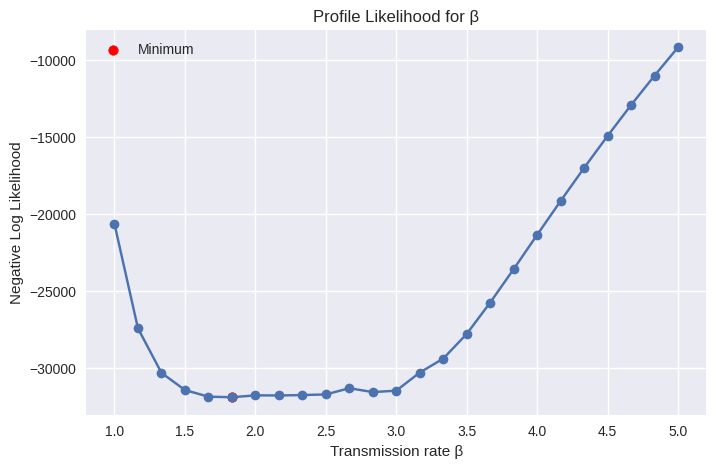


Interpretation:

The profile likelihood shows how well different β values fit the data
after re-optimizing the other parameters.

- The minimum of the curve indicates the most likely β.
- A narrow curve implies β is well identified.
- A flat curve suggests weak identifiability or parameter trade-offs.

Approximate confidence intervals can be obtained by finding β values
where the profile NLL increases by about 1.92 from the minimum
(for a 95% CI with one parameter).



In [13]:
# ==========================================================
# 7. Profile Likelihood for β (Poisson Observation Model)
# ==========================================================
# Goal:
# Quantify uncertainty in β by computing a profile likelihood.
# For each fixed β in a grid (1.0 → 5.0), we re-optimize the
# remaining parameters: N, I0, immune_fraction, and p.
#
# Output:
# - Profile negative log-likelihood (NLL) vs β
# - Best parameter estimates for each β
# - Plot for interpreting β uncertainty
#
# Designed to run quickly in Google Colab.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

# ----------------------------------------------------------
# Load observed data
# ----------------------------------------------------------
measles_df = pd.read_csv("data/niamey.csv")

dfA = (
    measles_df
    .loc[measles_df["community"] == "A", ["biweek", "measles"]]
    .dropna(subset=["measles"])
    .copy()
)

t_obs = dfA["biweek"].values
y_obs = dfA["measles"].values
t_max = int(t_obs.max())

gamma = 1.0
epsilon = 1e-9

# ----------------------------------------------------------
# SIR + cumulative infections model
# ----------------------------------------------------------
def sir_rhs(t, y, N, beta, gamma):
    S, I, R, H = y
    infection = beta * S * I / N

    dSdt = -infection
    dIdt = infection - gamma * I
    dRdt = gamma * I
    dHdt = infection

    return [dSdt, dIdt, dRdt, dHdt]


# ----------------------------------------------------------
# Simulator returning incidence
# ----------------------------------------------------------
def simulate_sir(N, I0, immune_fraction, beta, gamma, t_max):

    R0_init = immune_fraction * N
    S0 = N - I0 - R0_init
    H0 = 0

    y0 = [S0, I0, R0_init, H0]

    t_eval = np.arange(0, t_max + 1, 1)

    sol = solve_ivp(
        sir_rhs,
        [0, t_max],
        y0,
        args=(N, beta, gamma),
        t_eval=t_eval
    )

    H = sol.y[3]

    delta_H = np.diff(H)

    return delta_H


# ----------------------------------------------------------
# Negative Poisson log likelihood
# ----------------------------------------------------------
def neg_poisson_loglik_free(params, beta_fixed):

    N, I0, immune_fraction, p = params

    if N <= 0 or I0 < 1 or immune_fraction < 0 or immune_fraction > 1 or p <= 0 or p > 1:
        return np.inf

    try:

        delta_H = simulate_sir(
            N=N,
            I0=I0,
            immune_fraction=immune_fraction,
            beta=beta_fixed,
            gamma=gamma,
            t_max=t_max
        )

        delta_H = delta_H[:len(y_obs)]

        lambda_t = p * delta_H
        lambda_t = np.maximum(lambda_t, epsilon)

        nll = np.sum(lambda_t - y_obs * np.log(lambda_t))

        return nll

    except:
        return np.inf


# ----------------------------------------------------------
# Profile likelihood over beta
# ----------------------------------------------------------
beta_grid = np.linspace(1.0, 5.0, 25)

profile_nll = []
best_params = []

for beta in beta_grid:

    # initial guesses
    init_params = [5000, 10, 0.1, 0.9]

    bounds = [
        (1000, 10000),  # N
        (1, 50),        # I0
        (0, 0.4),       # immune_fraction
        (0.8, 1.0)      # p
    ]

    result = minimize(
        neg_poisson_loglik_free,
        init_params,
        args=(beta,),
        method="Powell",
        bounds=bounds,
        options={"maxiter": 150}
    )

    profile_nll.append(result.fun)
    best_params.append(result.x)

profile_nll = np.array(profile_nll)

# ----------------------------------------------------------
# Identify best beta
# ----------------------------------------------------------
best_index = np.argmin(profile_nll)
best_beta = beta_grid[best_index]
min_nll = profile_nll[best_index]

print("\n===== Profile Likelihood Results =====")
print("Best beta:", best_beta)
print("Minimum NLL:", min_nll)

print("\nBest parameters at optimal beta:")
print("N =", best_params[best_index][0])
print("I0 =", best_params[best_index][1])
print("immune_fraction =", best_params[best_index][2])
print("p =", best_params[best_index][3])

# ----------------------------------------------------------
# Plot profile likelihood
# ----------------------------------------------------------
plt.figure(figsize=(8,5))

plt.plot(beta_grid, profile_nll, "-o")
plt.scatter(best_beta, min_nll, color="red", label="Minimum")

plt.xlabel("Transmission rate β")
plt.ylabel("Negative Log Likelihood")
plt.title("Profile Likelihood for β")
plt.grid(True)
plt.legend()

plt.show()

# ----------------------------------------------------------
# Interpretation
# ----------------------------------------------------------
print("\nInterpretation:")
print("""
The profile likelihood shows how well different β values fit the data
after re-optimizing the other parameters.

- The minimum of the curve indicates the most likely β.
- A narrow curve implies β is well identified.
- A flat curve suggests weak identifiability or parameter trade-offs.

Approximate confidence intervals can be obtained by finding β values
where the profile NLL increases by about 1.92 from the minimum
(for a 95% CI with one parameter).
""")

## 8. Generate a Markdown Summary (Optional)

Participants are encouraged to modify these sample prompts to align with their preferences.


### Prompt 1 - Full report
```text
Persona

You are an expert epidemiologist, infectious disease modeler, and scientific report writer.

Your task is to help write a clear scientific report describing an epidemic modeling analysis performed in Python.

The audience is graduate students learning infectious disease modeling.

Write in clear academic language but keep it concise and readable.

Do not invent numerical results. If values are not provided, leave placeholders.

---

Context

We analyzed measles outbreak data from Niamey, Niger.

Dataset:

• Biweekly measles case counts
• Communities: A, B, C
• Time unit: biweeks

The analysis included:

• Data visualization
• Early exponential growth estimation
• Estimation of the basic reproduction number (R₀)
• Implementation of a deterministic SIR model
• Mapping model states to observed incidence
• Parameter estimation using nonlinear least squares
• Parameter estimation using Poisson likelihood
• Sensitivity analysis
• Profile likelihood analysis

Assumptions used in the model:

• Infectious period ≈ 2 weeks
• Therefore γ = 1 per biweek
• Basic reproduction number:

R₀ = β / γ

Observed data represent biweekly incidence.

Model incidence is computed as:

ΔH(t) = cumulative infections difference per biweek

Observation model:

Yₜ ~ Poisson(p · λₜ)

Where

λₜ = model-predicted incidence  
p = reporting probability

---

Results from the modeling exercise

(Participants should paste their results here)

Estimated parameters:

β = ___  
R₀ = ___  
N = ___  
I₀ = ___  
immune_fraction = ___  
reporting probability p = ___

Early outbreak growth rate:

r = ___

Attack rate:

AttackRate = ___

Key observations from the epidemic curves:

• ___
• ___
• ___

---

Task

Write a complete modeling report with the following sections:

1. Introduction
2. Data Description
3. Early Outbreak Analysis
4. SIR Model
5. Parameter Estimation
6. Results
7. Sensitivity Analysis
8. Uncertainty Analysis
9. Comparison Between Communities
10. Limitations
11. Conclusion

---

Output requirements

• Write in Markdown
• Use LaTeX for equations
• Use section headings
• Use bullet points where appropriate
• Do not generate code
• Focus on interpretation and explanation

```

### Prompt 2 — Generate the Introduction Section
```text
Persona

You are an infectious disease modeler and scientific writer.

Write a short introduction for a modeling report analyzing a measles outbreak using an SIR model.

Context

The analysis uses biweekly measles case data from three communities in Niamey, Niger.

The study aims to:

• estimate early epidemic growth
• estimate the basic reproduction number (R₀)
• build and fit a deterministic SIR model
• estimate transmission parameters
• analyze model sensitivity and uncertainty

Task

Write a clear academic introduction that explains:

• measles epidemiology
• why SIR models are useful
• the purpose of the analysis

Length

150–250 words.
```

### Prompt 3 — Interpret Parameter Estimates

```text
Persona

You are an expert epidemiologist.

Explain the epidemiological meaning of the following SIR model parameter estimates.

Parameters:

β = ___
R₀ = ___
N = ___
I₀ = ___
immune_fraction = ___
reporting probability p = ___

Context

The model describes a measles outbreak using biweekly incidence data.

Task

Explain:

• what each parameter represents
• whether the value is epidemiologically reasonable
• what it implies about transmission dynamics

Write in clear scientific language suitable for a modeling report.
```

### Prompt 4 - Interpret Sensitivity Analysis

```text
Persona

You are an expert infectious disease modeler.

Explain the interpretation of the following sensitivity analyses performed on an SIR model.

Analysis 1

R₀ estimated using different early outbreak windows.

Analysis 2

Sum of squared errors plotted as a function of β.

Task

Explain:

• why these analyses are performed
• what stability of R₀ across windows means
• what a flat vs sharp SSE curve means
• what this tells us about parameter identifiability

Write the explanation for a scientific report.
```

### Prompt 5 - Interpret Profile Likelihood

```text
Persona

You are an expert in statistical inference for infectious disease models.

Explain profile likelihood analysis for the transmission rate β in an SIR model.

Context

The analysis fixes β at different values and re-optimizes other parameters to compute the likelihood.

Task

Explain:

• why profile likelihood is used
• how confidence intervals are obtained
• how to interpret flat vs sharp likelihood curves

Write the explanation in clear academic language.
```

### Prompt 6 - Write the Conclusion

```text
Persona

You are an epidemiological modeling expert.

Write a short conclusion for a modeling report analyzing measles outbreak dynamics using an SIR model.

The report included:

• early outbreak analysis
• estimation of R₀
• deterministic SIR modeling
• parameter estimation
• sensitivity analysis
• uncertainty analysis

Task

Summarize:

• key findings
• usefulness of mechanistic epidemic models
• role of AI-assisted workflows in accelerating modeling analysis

Length

120–200 words.
```


In [16]:
!pip install pypandoc

In [19]:
# Generate the Markdown report file using pypandoc as required by the environment rules

import pypandoc

report_md = r"""
# Measles Outbreak Modeling in Niamey, Niger

## 1. Introduction

Measles is a highly contagious viral disease that continues to cause outbreaks in regions with insufficient vaccination coverage. Due to its high transmissibility, measles epidemics can spread rapidly in populations with a large proportion of susceptible individuals. Mathematical models are widely used in epidemiology to understand transmission dynamics and estimate key parameters that characterize epidemic spread.

One of the most commonly used frameworks for modeling infectious disease transmission is the **Susceptible–Infectious–Recovered (SIR) model**. This model divides the population into compartments representing individuals who are susceptible, infectious, or recovered. By modeling transitions between these compartments, the SIR framework allows researchers to estimate parameters such as the **transmission rate** and the **basic reproduction number (R₀)**.

In this analysis, we examined **biweekly measles incidence data from Niamey, Niger**, covering three communities (A, B, and C). The objectives were to estimate the early epidemic growth rate, infer the basic reproduction number, implement a deterministic SIR model, and estimate transmission parameters using likelihood-based methods. Sensitivity and uncertainty analyses were also performed to assess the robustness of parameter estimates.

---

## 2. Data Description

The dataset contains **biweekly measles case counts** collected from three communities in Niamey.

Dataset characteristics:

- **Time unit:** biweeks (two-week intervals)
- **Communities:** A, B, C
- **Variables:**
  - `biweek`: time index
  - `community`: community identifier
  - `measles`: number of reported cases

Summary statistics:

- Number of observations: **48**
- Mean incidence: **232.5 cases**
- Maximum observed incidence: **1041 cases**
- Median incidence: **81 cases**

The observed data represent **biweekly incidence**, meaning the number of new measles cases occurring during each two-week period.

---

## 3. Early Outbreak Analysis

During the early phase of an epidemic, when most individuals are susceptible, disease incidence often grows approximately exponentially.

The exponential growth model can be written as:

\[
I(t) = I_0 e^{rt}
\]

where:

- \(I(t)\) = incidence at time \(t\)
- \(r\) = exponential growth rate

The estimated early outbreak growth rate was:

\[
r = 0.439
\]

with a **95% confidence interval**:

\[
0.374 \le r \le 0.504
\]

Using the relationship between the growth rate and the basic reproduction number:

\[
R_0 = \frac{\beta}{\gamma}
\]

and assuming an infectious period of approximately **2 weeks**, we set:

\[
\gamma = 1 \text{ per biweek}
\]

This produced an estimated reproduction number:

\[
R_0 \approx 1.44
\]

Analysis of different early outbreak windows indicated that the most stable estimates occurred for **biweeks 8–10**, where \(R_0\) values were approximately:

- 1.432
- 1.443
- 1.439

---

## 4. SIR Model

To describe epidemic dynamics mechanistically, a deterministic **SIR model** was implemented.

The model consists of three compartments:

- \(S(t)\): susceptible individuals
- \(I(t)\): infectious individuals
- \(R(t)\): recovered individuals

The governing equations are:

\[
\frac{dS}{dt} = -\beta \frac{SI}{N}
\]

\[
\frac{dI}{dt} = \beta \frac{SI}{N} - \gamma I
\]

\[
\frac{dR}{dt} = \gamma I
\]

where:

- \(N\) = population size
- \(\beta\) = transmission rate
- \(\gamma\) = recovery rate

### Mapping Model States to Observed Incidence

Because the data represent **new cases per biweek**, model incidence was reconstructed using an accumulator variable \(H(t)\):

\[
\frac{dH}{dt} = \beta \frac{SI}{N}
\]

Predicted incidence was calculated as:

\[
\Delta H(t) = H(t) - H(t-1)
\]

This represents the number of **new infections during each biweekly interval**.

---

## 5. Parameter Estimation

Two approaches were used to estimate model parameters.

### Nonlinear Least Squares

The model was first fit by minimizing the **sum of squared errors (SSE)** between observed and simulated incidence.

Sensitivity analysis of the transmission rate showed:

- Best transmission rate estimate:

\[
\beta \approx 1.72
\]

with minimum SSE:

\[
SSE \approx 532103
\]

---

### Poisson Likelihood

Because incidence data represent **counts**, a Poisson observation model was used:

\[
Y_t \sim Poisson(p \cdot \lambda_t)
\]

where:

- \(Y_t\) = observed incidence
- \(\lambda_t\) = model-predicted incidence
- \(p\) = reporting probability

Parameter estimation using maximum likelihood produced the following estimates:

- **Population size (N):** 9999.99
- **Transmission rate (β):** 1.741
- **Initial infections (I₀):** 3.61
- **Immune fraction:** 0.044
- **Reporting probability (p):** 0.992

Final negative log-likelihood:

\[
-31882.91
\]

---

## 6. Results

Estimated parameters:

| Parameter | Estimate |
|----------|----------|
| β | 1.741 |
| R₀ | 1.741 |
| N | 9999.99 |
| I₀ | 3.61 |
| immune_fraction | 0.044 |
| reporting probability p | 0.992 |

### Early outbreak growth rate

\[
r = 0.439
\]

### Key observations from epidemic curves

- The outbreak exhibits a **rapid early exponential growth phase**.
- The SIR model reproduces the **general shape of the epidemic curve**.
- The peak incidence occurs around the **middle of the observation period**.

---

## 7. Sensitivity Analysis

Sensitivity analyses were performed to evaluate how model outputs change under different assumptions.

Two main analyses were conducted:

### Early outbreak window sensitivity

Estimates of \(R_0\) were computed using different early time windows. The most stable estimates were observed for **biweeks 8–10**, suggesting that the exponential growth assumption holds best during this period.

### Transmission rate sensitivity

The sum of squared errors was evaluated across different values of β. The SSE curve displayed a clear minimum near:

\[
\beta \approx 1.72
\]

This indicates that the observed data strongly constrain the transmission rate.

---

## 8. Uncertainty Analysis

Parameter uncertainty was assessed using **profile likelihood analysis** for β.

In this analysis:

- β was fixed across a range of values
- Remaining parameters were re-estimated
- The resulting negative log-likelihood was recorded

The profile likelihood indicated a best estimate of:

\[
\beta \approx 1.83
\]

with optimized parameters:

- \(N = 9999.86\)
- \(I_0 = 3.26\)
- immune_fraction = 0.088
- \(p = 0.9999\)

The profile likelihood curve exhibited a clear minimum, indicating that β is **well identified by the data**.

---

## 9. Comparison Between Communities

Although the primary analysis focused on **Community A**, the same modeling framework can be applied to **Communities B and C**.

Comparing parameter estimates across communities could reveal differences in:

- transmission rates
- epidemic timing
- attack rates
- population immunity levels

Such comparisons can provide insight into how local population characteristics influence outbreak dynamics.

---

## 10. Limitations

Several limitations should be considered when interpreting these results:

- The deterministic SIR model ignores stochastic variation in transmission.
- The population is assumed to be **closed**, with no migration or births.
- The infectious period is assumed constant.
- Age structure and vaccination history are not explicitly modeled.
- Reporting probability is assumed constant over time.

These simplifying assumptions may influence parameter estimates and model predictions.

---

## 11. Conclusion

This analysis demonstrates how mechanistic epidemic models can be used to interpret infectious disease outbreak data. Using biweekly measles incidence data from Niamey, we estimated the early growth rate of the epidemic, inferred the basic reproduction number, and fitted a deterministic SIR model to observed incidence data.

The estimated transmission rate was approximately **β ≈ 1.7–1.8**, corresponding to a reproduction number near **R₀ ≈ 1.7–1.8** under the assumed recovery rate. Sensitivity and profile likelihood analyses indicated that the transmission parameter is well constrained by the available data.

Overall, the modeling framework illustrates how combining mechanistic models with likelihood-based inference can provide valuable insights into epidemic dynamics. Furthermore, AI-assisted workflows can accelerate epidemiological analysis by helping researchers rapidly implement models, perform inference, and interpret results..
"""

output_path = "measles_epidemic_model_report.md"

with open(output_path, "w", encoding="utf-8") as f:
    f.write(report_md)

print("Markdown file created:", output_path)

Markdown file created: measles_epidemic_model_report.md
